# Quantum Annealing - Topology Constraint (Bonus TODO 7)

We compare the spectral gap of an Ising instance with and without duplicated nodes.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from Problem.IsingProblem import IsingProblem
from quantum_solver.dwave_simulator import (DwaveSimulator, plot_eigenvalues,
    plot_spectral_gap, create_ising_instance_random, create_ising_with_duplicated_node)

## Compare original instance vs instance with duplicated node

In [2]:
# Create a small instance (5 variables)
ising_original = create_ising_instance_random(5, weight_range=1.0, seed=42)
print(f"Original instance : {ising_original.n} variables")

# Duplicate node 0 with strong coupling
ising_dup = create_ising_with_duplicated_node(ising_original, node_to_duplicate=0, coupling_strength=5.0)
print(f"Duplicated instance : {ising_dup.n} variables")

sim = DwaveSimulator(n_steps=101)

Original instance : 5 variables
Duplicated instance : 6 variables


In [3]:
# Simulate both
eigs_orig, _ = sim.simulate_evolution(ising_original, nb_eigenvalues=5)
eigs_dup, _ = sim.simulate_evolution(ising_dup, nb_eigenvalues=5)

gaps_orig = [eigs_orig[s][1] - eigs_orig[s][0] for s in range(101)]
gaps_dup = [eigs_dup[s][1] - eigs_dup[s][0] for s in range(101)]

print(f"Min gap original (n={ising_original.n}) : {min(gaps_orig):.6f}")
print(f"Min gap duplicated (n={ising_dup.n}) : {min(gaps_dup):.6f}")

Min gap original (n=5) : 0.436110
Min gap duplicated (n=6) : 0.173548


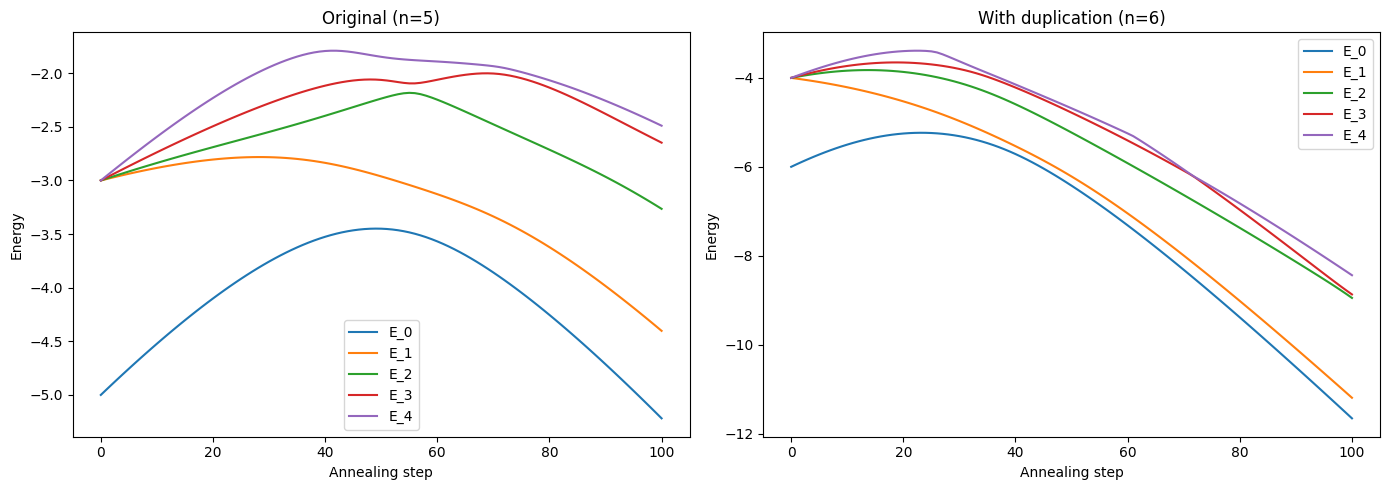

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
plot_eigenvalues(eigs_orig, title=f"Original (n={ising_original.n})")

plt.sca(axes[1])
plot_eigenvalues(eigs_dup, title=f"With duplication (n={ising_dup.n})")

plt.tight_layout()
plt.show()

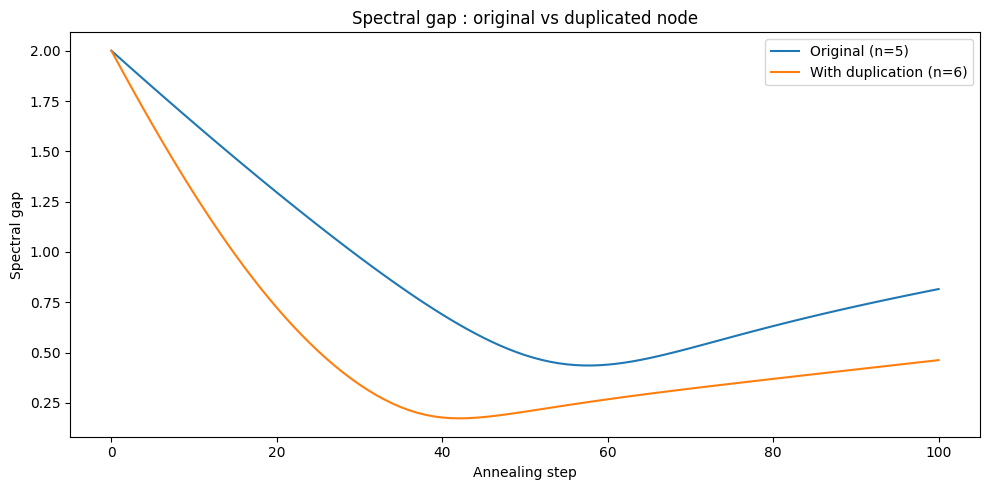

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(gaps_orig, label=f'Original (n={ising_original.n})')
plt.plot(gaps_dup, label=f'With duplication (n={ising_dup.n})')
plt.xlabel('Annealing step')
plt.ylabel('Spectral gap')
plt.title('Spectral gap : original vs duplicated node')
plt.legend()
plt.tight_layout()
plt.show()

## Multiple duplications

In [6]:
# Start with a small instance (4 variables) to keep things manageable
ising_base = create_ising_instance_random(4, weight_range=1.0, seed=10)

# Test with 0, 1, 2, 3 duplications of node 0
results_dup = {}
current_ising = ising_base

for n_dup in range(4):
    eigs, _ = sim.simulate_evolution(current_ising, nb_eigenvalues=2)
    gaps = [eigs[s][1] - eigs[s][0] for s in range(101)]
    results_dup[n_dup] = {'min_gap': min(gaps), 'gaps': gaps, 'n_vars': current_ising.n}
    print(f"{n_dup} duplications (n={current_ising.n}) : min gap = {min(gaps):.6f}")
    # Add another duplication for next round
    if n_dup < 3:
        current_ising = create_ising_with_duplicated_node(current_ising, node_to_duplicate=0, coupling_strength=5.0)

0 duplications (n=4) : min gap = 0.936852
1 duplications (n=5) : min gap = 0.839545
2 duplications (n=6) : min gap = 0.674234


3 duplications (n=7) : min gap = 0.561526


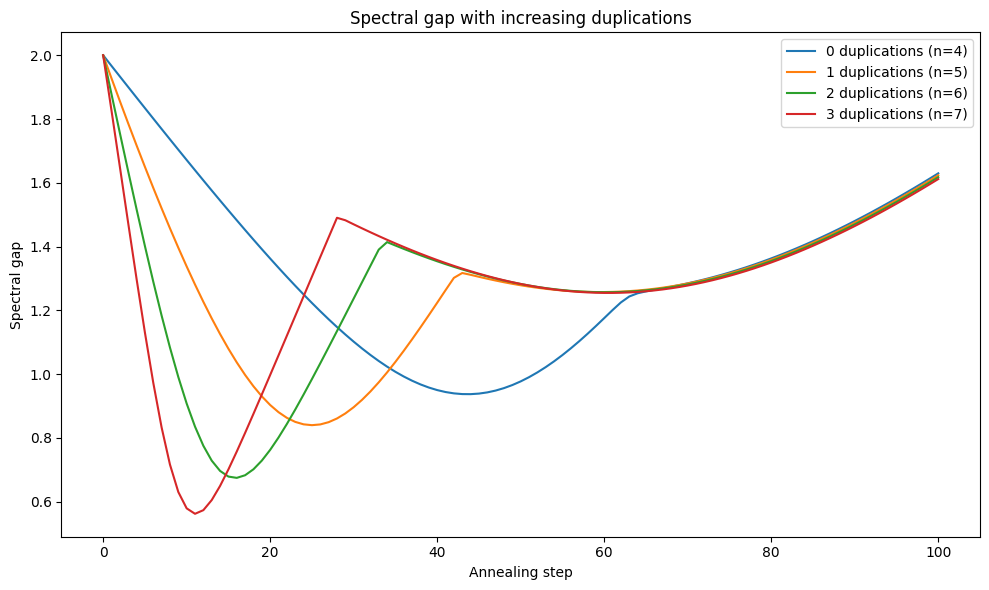

In [7]:
plt.figure(figsize=(10, 6))
for n_dup, data in results_dup.items():
    plt.plot(data['gaps'], label=f"{n_dup} duplications (n={data['n_vars']})")
plt.xlabel('Annealing step')
plt.ylabel('Spectral gap')
plt.title('Spectral gap with increasing duplications')
plt.legend()
plt.tight_layout()
plt.show()

## Analysis

**Effect of duplication on spectral gap :**

When we duplicate a node, we add an extra variable to the system. This increases the Hilbert space dimension from 2^n to 2^(n+1), doubling the matrix size. Even though the strong coupling F_phi forces the duplicated variables to be the same, the larger Hilbert space generally leads to a **smaller** spectral gap.

Each additional duplication makes the gap smaller because :
- The system has more degrees of freedom
- The energy landscape becomes more complex
- The strong coupling adds structure but doesn't compensate for the increased dimensionality

**What if F_phi is too strong for the programming range ?**

If the coupling F_phi is too large to be programmed (e.g., if J_ij is limited to [-2, +2] but we need F_phi = -5), we need to rescale all the weights of the problem to make F_phi fit within the programming range. This means dividing all weights (including h_i and J_ij) by a factor to bring F_phi within bounds.

This rescaling **worsens** the resolution because :
- All the energy differences in the problem become smaller
- The spectral gap shrinks proportionally to the rescaling factor
- The problem becomes more sensitive to noise and thermal fluctuations
- The signal-to-noise ratio decreases

So in practice, node duplication is costly : it increases the system size (worse gap) AND may force rescaling if the coupling is strong (even worse gap). This is why the embedding problem (mapping logical qubits to physical qubits with limited connectivity) is one of the main challenges for real quantum annealers.